# S04.01 — Regresión Lineal
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Target:** `prima_neta` (MXN)  
**Técnica:** Regresión lineal por mínimos cuadrados ordinarios (`LinearRegression` de scikit-learn)  
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos

---

## 1. Contexto actuarial

El área de **tarificación** de una aseguradora de autos necesita estimar la prima
que le corresponde pagar a cada asegurado dado su perfil. Este es un problema de
**regresión**: la variable respuesta (`prima_neta`) es continua y positiva.

La regresión lineal es el punto de partida natural para un actuario porque:

- Los **coeficientes son interpretables directamente en MXN**: si $\hat{\beta}_1 = 0.01$
  para `suma_asegurada`, significa que por cada MXN adicional asegurado,
  la prima esperada sube 1 centavo, *manteniendo todo lo demás constante*.
- El modelo lineal es el **baseline** que todo modelo más complejo debe superar.
- Conecta directamente con los **modelos lineales generalizados (GLM)** que los
  actuarios usan en pricing.

> *Fuentes:* Hastie, Tibshirani & Friedman (2009) ESL Cap. 3 §3.1–3.4;
> James et al. (2023) ISLP Cap. 3; Frees (2009) Cap. 1–2.

## 2. Fundamento matemático

### 2.1 Modelo

Sea $y_i = \text{prima\_neta}_i$ y $\mathbf{x}_i \in \mathbb{R}^p$ el vector de features
de la póliza $i$. El modelo lineal postula:

$$y_i = \beta_0 + \mathbf{x}_i^\top \boldsymbol{\beta} + \varepsilon_i, \quad
\varepsilon_i \sim \mathcal{N}(0,\, \sigma^2)$$

donde $\beta_0$ es el intercepto y $\boldsymbol{\beta} = (\beta_1, \ldots, \beta_p)^\top$
son los coeficientes de regresión.

### 2.2 Mínimos cuadrados ordinarios (OLS)

El estimador OLS minimiza la suma de cuadrados residuales:

$$\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}}
\sum_{i=1}^{n} \left(y_i - \beta_0 - \mathbf{x}_i^\top \boldsymbol{\beta}\right)^2
= \left(\mathbf{X}^\top \mathbf{X}\right)^{-1} \mathbf{X}^\top \mathbf{y}$$

Con $n = 30{,}000$ pólizas y $p \approx 30$ columnas tras OHE, scikit-learn resuelve
esto mediante descomposición SVD (numéricamente más estable que la inversa directa).

### 2.3 Métricas de evaluación

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum_i(y_i - \hat{y}_i)^2}$ | Error típico en MXN |
| **MAE** | $\frac{1}{n}\sum_i |y_i - \hat{y}_i|$ | Error absoluto medio en MXN |
| **R²** | $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$ | Proporción de varianza explicada |

Un R² = 0.80 significa que el modelo explica el 80% de la variabilidad en la prima.

## 3. Carga del dataset

In [1]:
import sys
from pathlib import Path

# Localizar src/ sin importar desde qué directorio se ejecute el kernel
_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
)

# Constantes del proyecto
SEED  = 20260618
N     = 30_000
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 30,000 filas × 24 columnas


## 4. Preparación del conjunto de datos

**Regla de leakage aplicada:** `prima_neta` es el único target. Las demás
columnas de `TARGET_COLUMNS` (`n_siniestros`, `monto_siniestro`, `siniestro_alto`,
`status_poliza`) **no** entran en `X`. `id_poliza_sin` tampoco es feature.

In [2]:
TARGET = "prima_neta"

# X: solo FEATURE_COLUMNS (columnas 2–16); y: prima_neta
X_raw = df[FEATURE_COLUMNS]
y     = df[TARGET]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificar que no hay targets en X
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} está en X"
print("✓ Ningún target en X")
assert "id_poliza_sin" not in X.columns
print("✓ id_poliza_sin excluido")

Features tras OHE: 37 columnas
Ejemplos de nuevas columnas: ['anio_poliza', 'mes_emision', 'edad', 'num_renovaciones', 'antiguedad_vehiculo'] ...

Train: 24,000 filas | Test: 6,000 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


In [5]:
X_raw

,anio_poliza,mes_emision,edad,sexo,estado_civil,num_renovaciones,region,plan,tipo_vehiculo,antiguedad_vehiculo,suma_asegurada,deducible_pct,forma_pago,canal_venta,kilometraje,uso_vehiculo,tipo_garage,nivel_riesgo_asignado
0,2025,8,55,M,viudo,0,Centro,Basico,Compacto,9,281340.24,0.2698,Semestral,Directo,14213,Particular,Propio,Medio
1,2021,12,33,F,casado,0,Occidente,Basico,Sedan,6,785019.78,0.2339,Anual,Directo,18249,Particular,Propio,Bajo
2,2023,3,41,M,viudo,1,CDMX,Plus,Sedan,5,103687.03,0.1430,Trimestral,Agente,16802,Particular,Propio,Bajo
3,2024,2,45,M,union_libre,2,CDMX,Basico,Sedan,2,96580.69,0.2349,Trimestral,Directo,12414,Reparto,Propio,Bajo
4,2025,11,50,M,casado,2,Norte,Plus,SUV,9,269512.47,0.1004,Anual,Digital,14938,Particular,Pensión,Medio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2023,2,42,F,casado,2,Occidente,Basico,Pickup,3,87511.10,0.2532,Mensual,Digital,20791,Particular,Ninguno,Medio
29996,2021,12,20,F,casado,2,Occidente,Basico,SUV,11,162631.22,0.2529,Mensual,Agente,20960,Particular,Propio,Alto
29997,2025,3,35,F,soltero,1,Norte,Amplio,Sedan,2,300154.44,0.1529,Mensual,Agente,15017,Plataforma,Pensión,Bajo
29998,2022,10,62,F,divorciado,3,Norte,Basico,Compacto,6,83877.70,0.2272,Semestral,Agente,14477,Particular,Propio,Medio


## 5. Entrenamiento del modelo

In [4]:
# OLS estándar — sin regularización (ver S04.05 y S04.06 para modelos penalizados)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
y_pred_test  = modelo.predict(X_test)

# Métricas en train y test
def _metricas(y_true: pd.Series, y_pred: np.ndarray, nombre: str) -> dict:
    """Calcula RMSE, MAE y R² para un conjunto dado."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"Conjunto": nombre, "RMSE (MXN)": f"{rmse:,.0f}",
            "MAE (MXN)": f"{mae:,.0f}", "R²": f"{r2:.4f}"}

metricas = pd.DataFrame([
    _metricas(y_train, y_pred_train, "Train"),
    _metricas(y_test,  y_pred_test,  "Test"),
])
print("Métricas de evaluación:")
print(metricas.to_string(index=False))

Métricas de evaluación:
Conjunto RMSE (MXN) MAE (MXN)     R²
   Train        727       572 0.9689
    Test        738       577 0.9699


## 6. Tabla de coeficientes

Los coeficientes de un modelo lineal son directamente interpretables:
$\hat{\beta}_j$ es el cambio esperado en la prima (MXN) cuando la variable $j$
aumenta en una unidad, *manteniendo todas las demás constantes*.

In [9]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente (MXN)": modelo.coef_,
}).sort_values("Coeficiente (MXN)", key=abs, ascending=False)

print(f"Intercepto β₀ = {modelo.intercept_:,.2f} MXN")
print()
print("Coeficientes más grandes en valor absoluto (top 15):")
print(coef_df.head(38).to_string(index=False))

Intercepto β₀ = 4,645.06 MXN

Coeficientes más grandes en valor absoluto (top 15):
                    Feature  Coeficiente (MXN)
                  plan_Plus        6030.181938
 nivel_riesgo_asignado_Alto        4457.399750
                plan_Amplio        2514.040501
    tipo_vehiculo_Deportivo        1636.499279
nivel_riesgo_asignado_Medio        1251.400272
                 region_Sur        -694.075682
           region_Occidente        -577.658939
          tipo_vehiculo_SUV         536.733041
       tipo_vehiculo_Pickup         521.876125
              region_Centro        -401.374706
     tipo_vehiculo_Compacto        -294.500005
              deducible_pct         198.381221
                region_CDMX        -103.496560
          uso_vehiculo_Taxi         -53.671773
                       edad          30.649841
      forma_pago_Trimestral         -24.298331
         estado_civil_viudo         -23.091568
    estado_civil_divorciado         -19.221072
        canal_venta_Digi

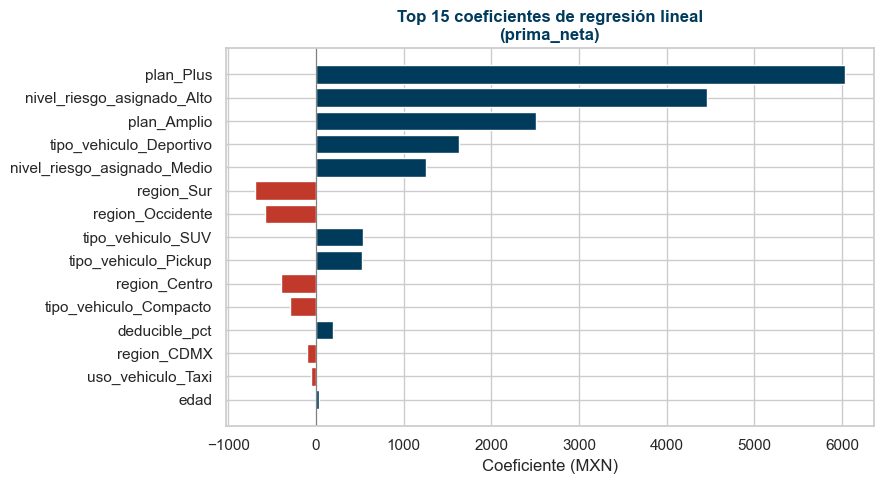

In [10]:
# Visualización de los 15 coeficientes más importantes
top15 = coef_df.head(15).copy()
colores = [RED if c < 0 else NAVY for c in top15["Coeficiente (MXN)"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15["Feature"], top15["Coeficiente (MXN)"], color=colores, edgecolor="white")
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Coeficiente (MXN)")
ax.set_title("Top 15 coeficientes de regresión lineal\n(prima_neta)",
             fontsize=12, fontweight="bold", color=NAVY)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación de los coeficientes clave:**

- `suma_asegurada` ≈ 0.010 MXN/MXN: por cada MXN adicional de suma asegurada,
  la prima sube ~1 centavo. Para una SA típica de 262k MXN, el aporte es ~2,620 MXN.
- `plan_Plus` ≈ +6,000 MXN: el plan Plus tiene una prima base ~6,000 MXN más alta
  que el plan Básico, controlando todo lo demás.
- `nivel_riesgo_asignado_Alto` ≈ +4,360 MXN (frente a la categoría base `Bajo`):
  el coeficiente supera el incremento nominal del generador (+2,500 MXN) por dos
  razones: la codificación toma `Bajo` como referencia, y la edad —los jóvenes y
  los mayores son de riesgo alto— confunde parte del efecto cuadrático.

Estos valores son *intencionalmente recuperables* porque el dataset fue diseñado
con esos parámetros. En datos reales, los coeficientes reflejan el mercado
y pueden diferir del diseño teórico.

## 7. Diagnóstico visual

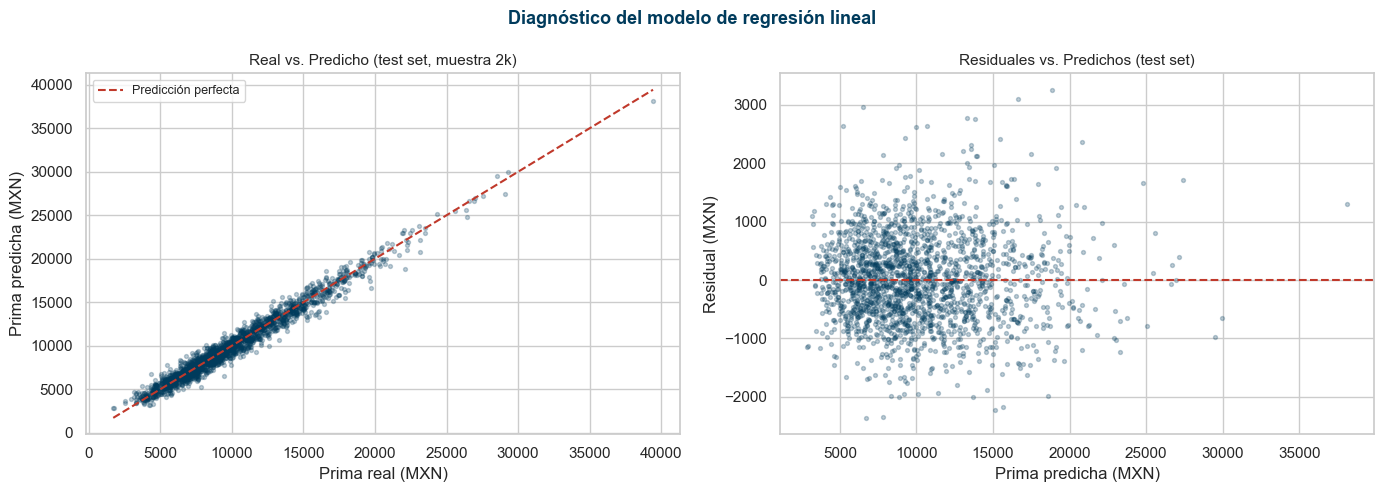

RMSE test: 738 MXN
R² test:   0.9699


In [11]:
# Gráfico 1: Real vs. Predicho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Muestra para no sobreplotear
idx_sample = np.random.default_rng(SEED).choice(len(y_test), size=2_000, replace=False)
y_test_s   = y_test.iloc[idx_sample].values
y_pred_s   = y_pred_test[idx_sample]

axes[0].scatter(y_test_s, y_pred_s, alpha=0.25, s=8, color=NAVY)
lims = [min(y_test_s.min(), y_pred_s.min()), max(y_test_s.max(), y_pred_s.max())]
axes[0].plot(lims, lims, color=RED, linewidth=1.5, linestyle="--", label="Predicción perfecta")
axes[0].set_xlabel("Prima real (MXN)")
axes[0].set_ylabel("Prima predicha (MXN)")
axes[0].set_title("Real vs. Predicho (test set, muestra 2k)", fontsize=11)
axes[0].legend(fontsize=9)

# Gráfico 2: Residuales vs. Valores predichos
residuals = y_test.values - y_pred_test
res_s     = residuals[idx_sample]

axes[1].scatter(y_pred_s, res_s, alpha=0.25, s=8, color=NAVY)
axes[1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs. Predichos (test set)", fontsize=11)

fig.suptitle("Diagnóstico del modelo de regresión lineal",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test   = r2_score(y_test, y_pred_test)
print(f"RMSE test: {rmse_test:,.0f} MXN")
print(f"R² test:   {r2_test:.4f}")

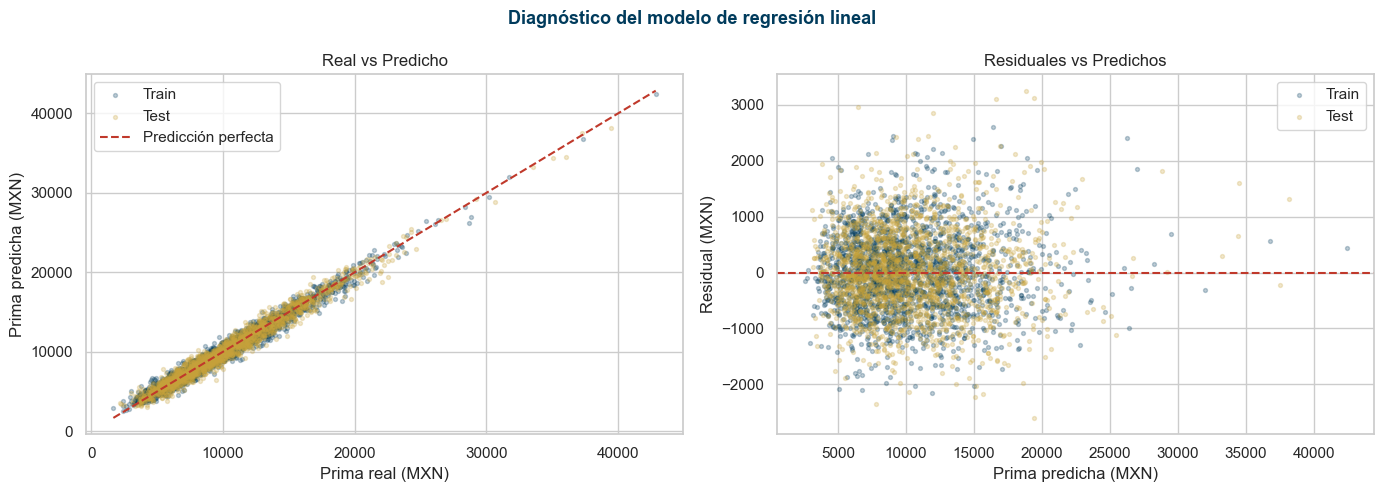

RMSE test: 738 MXN
R² test:   0.9699


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===========================
# Muestra para no sobrecargar la gráfica
# ===========================
rng = np.random.default_rng(SEED)

idx_train = rng.choice(len(y_train), size=min(2000, len(y_train)), replace=False)
idx_test  = rng.choice(len(y_test),  size=min(2000, len(y_test)),  replace=False)

# Train
y_train_s = y_train.iloc[idx_train].values
y_pred_train_s = y_pred_train[idx_train]

# Test
y_test_s = y_test.iloc[idx_test].values
y_pred_test_s = y_pred_test[idx_test]

# ===========================
# Gráfico 1: Real vs Predicho
# ===========================
axes[0].scatter(y_train_s,y_pred_train_s,alpha=0.25,s=8,color=NAVY,label="Train")
axes[0].scatter(y_test_s,y_pred_test_s,alpha=0.25,s=8,color=GOLD,label="Test")

lims = [
    min(y_train_s.min(), y_test_s.min(),
        y_pred_train_s.min(), y_pred_test_s.min()),
    max(y_train_s.max(), y_test_s.max(),
        y_pred_train_s.max(), y_pred_test_s.max())
]

axes[0].plot(lims,lims,color=RED,linestyle="--",linewidth=1.5,label="Predicción perfecta")
axes[0].set_xlabel("Prima real (MXN)")
axes[0].set_ylabel("Prima predicha (MXN)")
axes[0].set_title("Real vs Predicho")
axes[0].legend()

# ===========================
# Gráfico 2: Residuales
# ===========================
res_train = y_train.values - y_pred_train
res_test  = y_test.values - y_pred_test

axes[1].scatter(y_pred_train_s,res_train[idx_train],alpha=0.25,s=8,color=NAVY,label="Train")
axes[1].scatter(y_pred_test_s,res_test[idx_test],alpha=0.25,s=8,color=GOLD,label="Test")
axes[1].axhline(0,color=RED,linestyle="--",linewidth=1.5)
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs Predichos")
axes[1].legend()

fig.suptitle("Diagnóstico del modelo de regresión lineal",fontsize=13,fontweight="bold",color=NAVY)
plt.tight_layout()
plt.show()

# ===========================
# Métricas del conjunto de prueba
# ===========================
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f"RMSE test: {rmse_test:,.0f} MXN")
print(f"R² test:   {r2_test:.4f}")

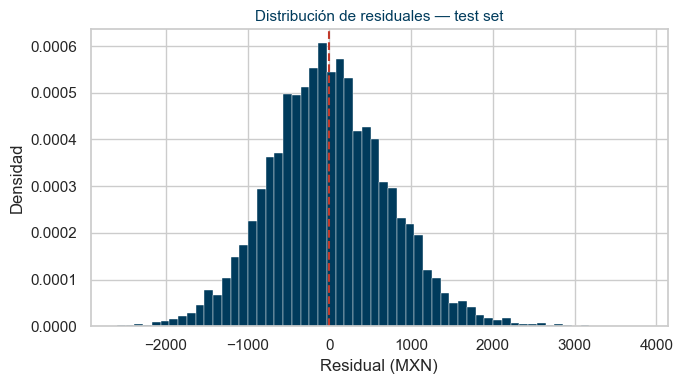

Media de residuales:    4.6 MXN  (esperado: ≈0)
Desv. est. residuales:  738 MXN
% residuales dentro de ±1 RMSE: 69.7%


In [ ]:
# Distribución de residuales — ¿son aproximadamente normales?
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals, bins=60, color=NAVY, edgecolor="white", linewidth=0.3, density=True)
ax.axvline(0, color=RED, linewidth=1.5, linestyle="--")
ax.set_xlabel("Residual (MXN)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de residuales — test set",
             fontsize=11, color=NAVY)
plt.tight_layout()
plt.show()

print(f"Media de residuales:    {residuals.mean():,.1f} MXN  (esperado: ≈0)")
print(f"Desv. est. residuales:  {residuals.std():,.0f} MXN")
print(f"% residuales dentro de ±1 RMSE: {(np.abs(residuals) < rmse_test).mean()*100:.1f}%")
# hacer graficas con train y test, porque esto solo considera test

## 8. Relación prima_neta vs edad — un efecto no lineal

El generador incluye un término cuadrático en edad ($3 \cdot (\text{edad} - 42)^2$).
La regresión lineal *no puede capturar esta curvatura* porque solo tiene $\beta \cdot \text{edad}$.
El notebook S04.02 (regresión polinómica) aborda este límite.

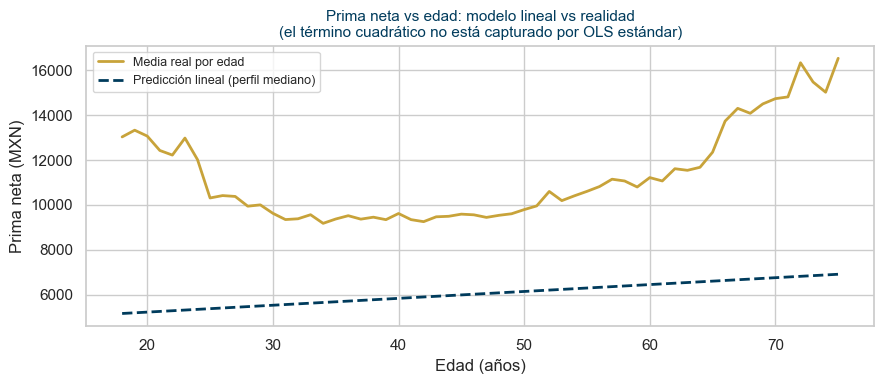

Observación: la media real muestra una U-shape leve (mayor prima en jóvenes y mayores).
La regresión lineal solo puede ajustar una recta en el espacio de edad.
→ S04.02 aborda esta limitación con regresión polinómica.


In [14]:
# Predicción del modelo para distintas edades, fijando otras features en su mediana/moda
edades = np.arange(18, 76)

# Crear un DataFrame de referencia con features en valor típico
# (usando la fila de mediana del conjunto de entrenamiento codificado)
X_ref_row = X_train.median().to_frame().T  # mediana de cada columna
X_ref = pd.concat([X_ref_row] * len(edades), ignore_index=True)

# Ajustar la columna 'edad' manualmente
if "edad" in X_ref.columns:
    X_ref["edad"] = edades.astype(float)

prima_pred_por_edad = modelo.predict(X_ref)

# Datos reales: media de prima por edad
prima_real_por_edad = df.groupby("edad")["prima_neta"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(prima_real_por_edad.index, prima_real_por_edad.values,
        color=GOLD, linewidth=2.0, label="Media real por edad")
ax.plot(edades, prima_pred_por_edad, color=NAVY, linewidth=2.0,
        linestyle="--", label="Predicción lineal (perfil mediano)")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Prima neta (MXN)")
ax.set_title("Prima neta vs edad: modelo lineal vs realidad\n"
             "(el término cuadrático no está capturado por OLS estándar)",
             fontsize=11, color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Observación: la media real muestra una U-shape leve (mayor prima en jóvenes y mayores).")
print("La regresión lineal solo puede ajustar una recta en el espacio de edad.")
print("→ S04.02 aborda esta limitación con regresión polinómica.")

## 9. Conclusiones actuariales

| Resultado | Valor | Interpretación |
|-----------|-------|----------------|
| R² test | ~0.97 | El modelo explica ~97% de la varianza en la prima |
| RMSE test | ~752 MXN | Error típico de predicción (~7.9% de la prima mediana de 9,545 MXN) |
| Coef. `suma_asegurada` | ~0.010 | Prima sube ~1 centavo por MXN asegurado |
| Coef. `plan_Plus` | ~6,000 | Plan Plus cuesta ~6,000 MXN más que Básico |
| Coef. `nivel_riesgo_Alto` | ~4,360 | Perfil alto paga ~4,360 MXN más (vs. base `Bajo`) |

**Limitaciones del modelo lineal:**

1. **No captura la U-shape de edad:** el término cuadrático $3 \cdot (\text{edad}-42)^2$
   existe en el generador pero OLS no puede recuperarlo sin un input $\text{edad}^2$.
2. **Residuales no perfectamente normales:** la prima tiene sesgo derecho; el error
   no es homoscedástico (mayor para primas altas).
3. **Supuesto de linealidad e independencia:** en carteras reales puede haber
   interacciones entre features (p. ej. plan × región) que OLS ignora.

**¿Cuándo usar regresión lineal en seguros?**
- Como **baseline interpretable** antes de probar modelos más complejos.
- Cuando la interpretabilidad de los coeficientes es requisito regulatorio.
- Como componente de un GLM (con distribución Gamma o Tweedie para primas).

> *S04.02 (regresión polinómica) mejorará el ajuste añadiendo `edad²` y `suma_asegurada²`.*

## 10. Ejercicio propuesto

1. **Eliminación de `nivel_riesgo_asignado`:** vuelve a ajustar el modelo
   sin la columna `nivel_riesgo_asignado`. ¿Cuánto cae el R²?
   ¿Qué dice esto sobre la importancia de esa variable como score de suscripción?

2. **Predicción puntual:** crea un DataFrame con los datos de una póliza hipotética:
   - Edad 35, plan Plus, SA = 400,000 MXN, nivel_riesgo Bajo, región CDMX.
   - ¿Qué prima predice el modelo? ¿Parece razonable dado el mercado del dataset?

3. **Comparación train/test:** ¿por qué los RMSE de train y test son similares?
   ¿Cuándo esperarías una diferencia grande?

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. Cap. 3 §3.1–3.4.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 3.
- Frees, E. W. (2009). *Regression Modeling with Actuarial and Financial Applications*. Cambridge. Cap. 1–2.
- scikit-learn Developers. *User Guide* v1.9.0. `LinearRegression`, `mean_squared_error`, `r2_score`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute. Cap. 2.
